# Plot EDA for cleaned UCI AQ dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("../data/processed/airquality_cleaned.csv")
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

aqi = pd.read_csv("../data/processed/aqi_cleaned.csv")
precip = pd.read_csv("../data/processed/precip_data_cleaned.csv")

df["time"] = range(len(df))
df.set_index("time", inplace=True)

aqi["Date"] = pd.to_datetime(aqi["Date"])
precip["DATE"] = pd.to_datetime(precip["DATE"])

### Plot `CO`, `NO2`, `O3` over time

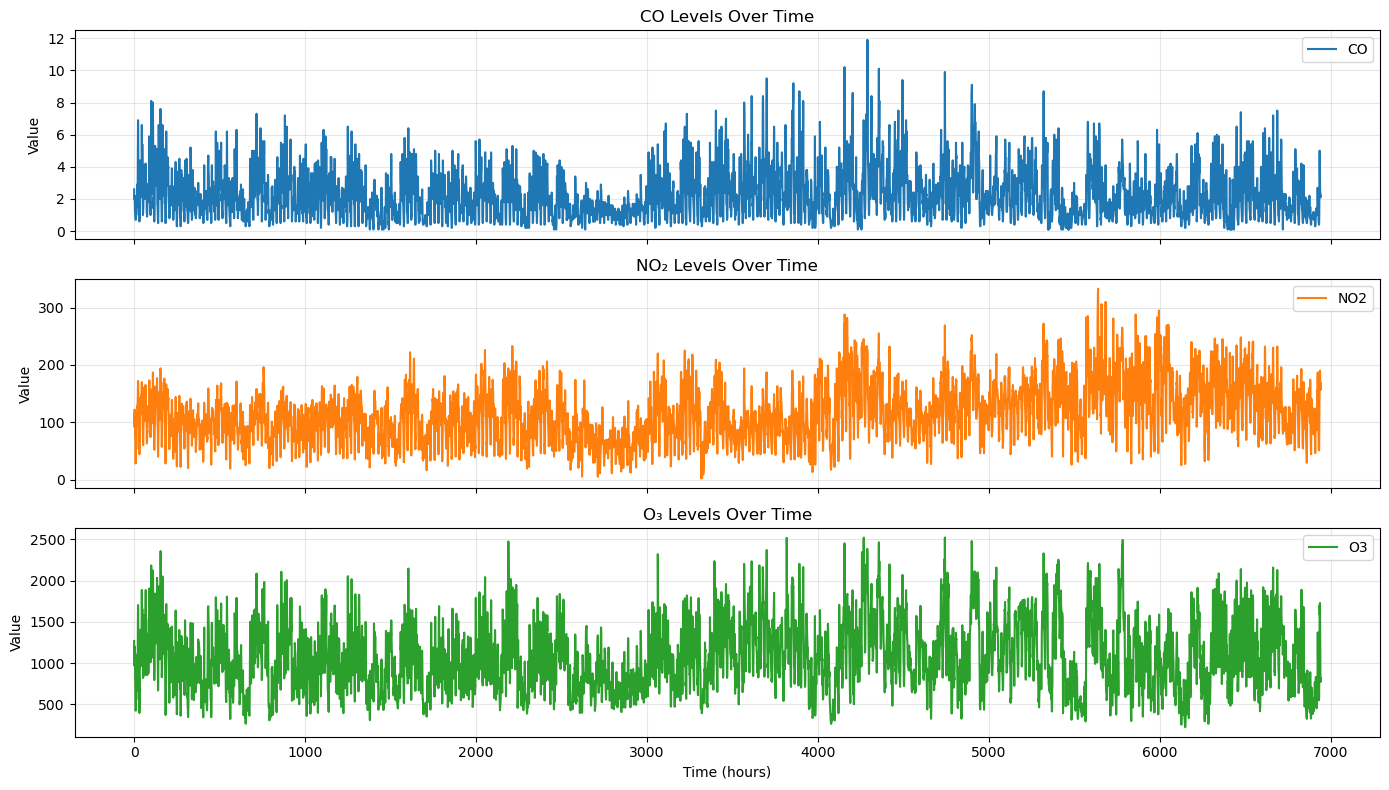

In [3]:
axes = df[["CO", "NO2", "O3"]].plot(
    figsize=(14, 8),
    subplots=True,
    sharex=True,
    legend=True
)

titles = ["CO Levels Over Time", "NO₂ Levels Over Time", "O₃ Levels Over Time"]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

These time-series plots show how each pollutant changes continuously over the entire observation period. Since air pollution fluctuates with traffic, weather, and human activity, visualizing pollutant trends over time helps you detect spikes, long-term patterns, and instability in air quality. This is the most direct way to understand when pollution worsens and whether the pollutants behave similarly across time.

- **CO levels fluctuate highly**, with frequent short-term spikes but no clear long-term upward or downward trend visible.
- **NO₂ shows similar repeated oscillations**, with slightly higher baseline variation, suggesting periodic emissions patterns (e.g., morning/evening traffic cycles).
- **O₃ values have the largest magnitude and strongest variability**, indicating ozone experiences more extreme highs and lows than CO and NO₂.
- **All three pollutants show continuous variation**, implying pollution sources operate consistently throughout the year.
- **Spikes appear synchronized across pollutants**, hinting that common conditions (temperature, traffic, or atmospheric chemistry) may influence them simultaneously.


### Plot correlation between `CO`, `NO2`, `O3`

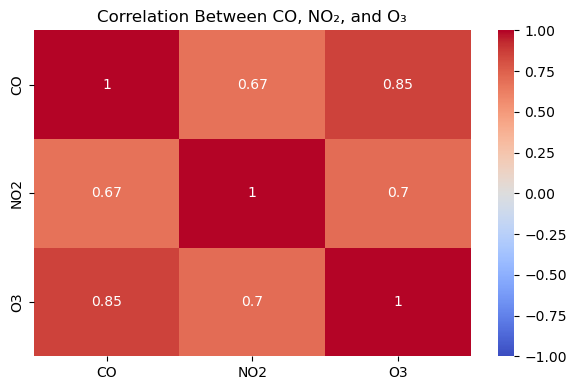

In [4]:
plt.figure(figsize=(6, 4))
corr = df[["CO", "NO2", "O3"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between CO, NO₂, and O₃")
plt.tight_layout()
plt.show()

The correlation heatmap quantifies how strongly each pollutant relates to the others. This is important because if pollutants rise and fall together, they may come from similar sources (such as vehicles or industrial output). High correlations also matter for modeling decisions, helping identify multicollinearity concerns in predictive models.

- **CO and O₃ have a very high correlation (0.85)**, suggesting strong co-movement likely influenced by shared atmospheric or emission conditions.
- **NO₂ is moderately to strongly correlated** with both CO (0.67) and O₃ (0.70), showing that all pollutants tend to rise and fall together.
- **All correlations are positive**, meaning increases in one pollutant are typically accompanied by increases in the others.
- **The heatmap visually emphasizes these strengths**, with darker red tones indicating stronger relationships.
- **These patterns suggest shared pollution sources**, such as combustion engines, industrial emissions, or weather influences.


### Merge AQI + Precipitation

In [10]:
aqi_precip = aqi.merge(precip, left_on="Date", right_on="DATE", how="left")
aqi_precip.drop(columns=["DATE"], inplace=True)


### Distribution of AQI Levels

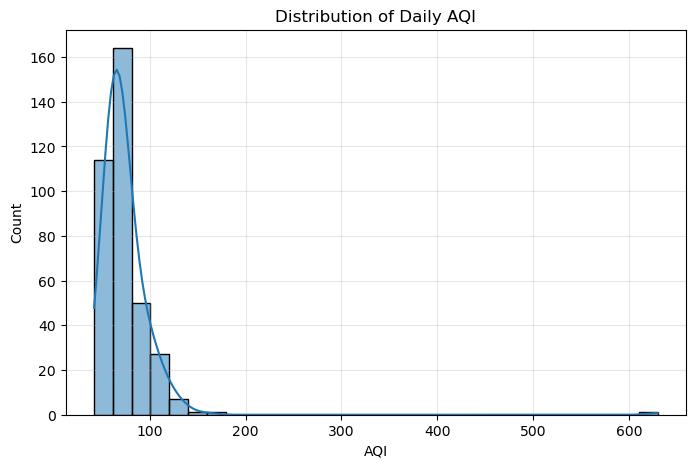

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(aqi["AQI"], bins=30, kde=True)
plt.title("Distribution of Daily AQI")
plt.xlabel("AQI")
plt.grid(alpha=0.3)
plt.show()


This histogram shows how AQI values are distributed across all days in the dataset. Understanding the distribution reveals whether the city experiences mostly good, moderate, or unhealthy air. It also highlights whether extreme pollution events are frequent or rare and how they influence overall air quality patterns.

- **The distribution is right-skewed**, meaning most days have moderate AQI, while a few days experience extreme pollution.
- **Most AQI values fall between ~50–120**, indicating generally moderate air quality for the majority of days.
- **A small number of extreme outlier days** appear above 200 and even beyond 600, representing severe pollution episodes.
- **The density curve shows its maximum concentration** in the **80–90 AQI range**, indicating that this is where most daily AQI values cluster.
- **The long tail indicates occasional hazardous conditions**, which have strong implications for public health and policy planning.